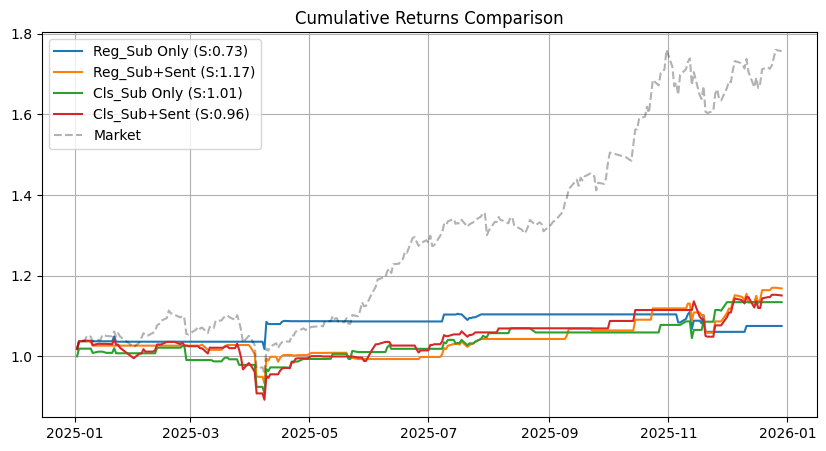

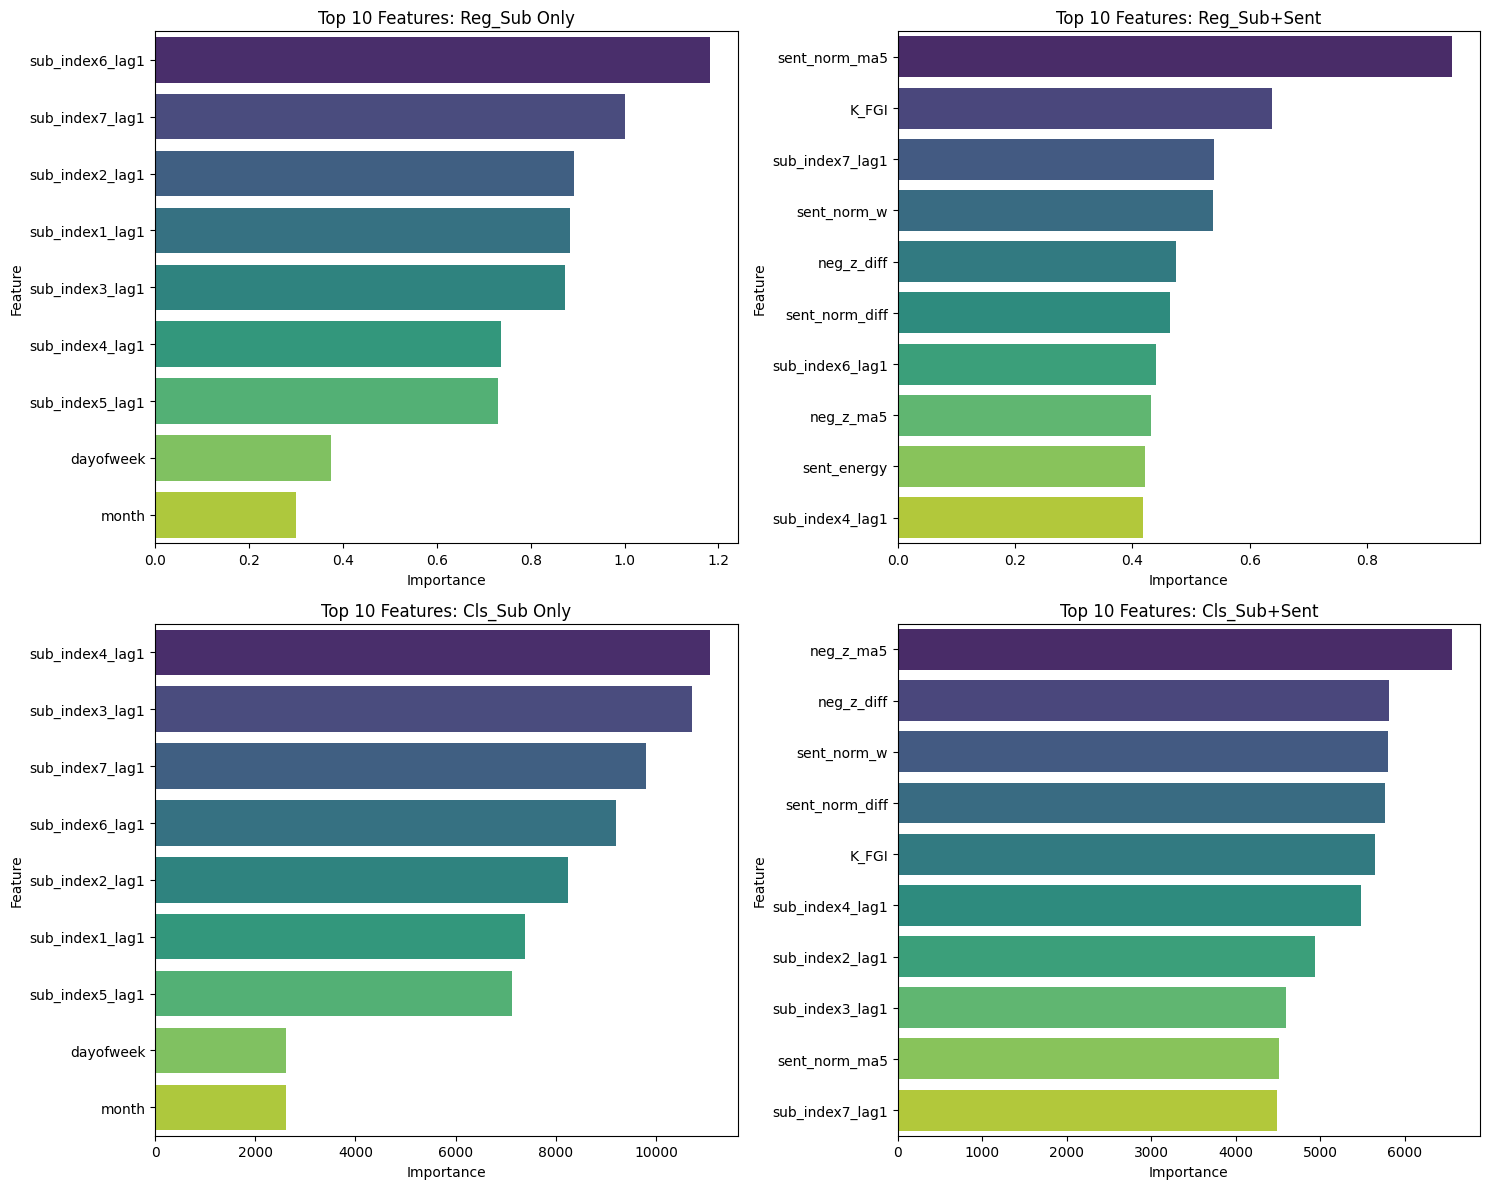


===== 벤치마크 결과 요약 =====
       Model  Sharpe Return
Reg_Sub Only   0.729  7.60%
Reg_Sub+Sent   1.173 16.27%
Cls_Sub Only   1.014 13.18%
Cls_Sub+Sent   0.959 14.70%


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 가이드 기반 피처 엔지니어링 (동일)
df = pd.read_csv('/content/drive/MyDrive/시계열 금융/KFG_final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')

def build_advanced_features(df):
    df = df.copy()
    df['neg_z_inv'] = -df['neg_z']
    df['sent_std_inv'] = -df['sent_std']
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']
    df['sent_norm_diff'] = df['sent_norm_w'].diff()
    df['neg_z_diff'] = df['neg_z'].diff()
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()

    sub_cols = [f'sub_index{i}' for i in range(1, 8)]
    for col in sub_cols:
        df[f'{col}_lag1'] = df[col].shift(1)

    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['target_reg'] = df['log_return_t+1']
    df['target_cls'] = (df['log_return_t+1'] > 0).astype(int)
    df['sample_weight'] = np.log1p(df['effective_n'])

    return df.dropna().reset_index(drop=True)

df_eng = build_advanced_features(df)

# 2. K-FGI 지수 생성 (Ridge)
def create_kfgi(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + \
                 ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv']
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df.loc[train_mask, core_feats])
    X_all_scaled = scaler.transform(df[core_feats])
    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0]).fit(X_train_scaled, df.loc[train_mask, 'target_reg'])
    w = ridge.coef_ / np.sum(np.abs(ridge.coef_))
    raw = X_all_scaled @ w
    p1, p99 = np.percentile(raw[train_mask], [1, 99])
    df['K_FGI'] = 100 * (np.clip(raw, p1, p99) - p1) / (p99 - p1)
    return df, core_feats

df_fgi, core_feats = create_kfgi(df_eng)

# 3. 통합 비교 실험 및 피처 중요도 분석
def run_full_analysis(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    test_mask = df['date'] > train_end

    sub_only = [f'sub_index{i}_lag1' for i in range(1, 8)] + ['dayofweek', 'month']
    with_sent = sub_only + ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                            'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5', 'K_FGI']

    experiments = [
        ('Reg', 'Sub Only', sub_only),
        ('Reg', 'Sub+Sent', with_sent),
        ('Cls', 'Sub Only', sub_only),
        ('Cls', 'Sub+Sent', with_sent)
    ]

    summary = []
    fig_cum, ax_cum = plt.subplots(figsize=(10, 5))
    fig_imp, axes_imp = plt.subplots(2, 2, figsize=(15, 12))
    axes_imp = axes_imp.flatten()

    for i, (m_type, f_type, f_list) in enumerate(experiments):
        target = 'target_reg' if m_type == 'Reg' else 'target_cls'

        # 모델 학습
        dtrain = lgb.Dataset(df.loc[train_mask, f_list], label=df.loc[train_mask, target],
                             weight=df.loc[train_mask, 'sample_weight'])
        params = {'objective': 'regression' if m_type == 'Reg' else 'binary', 'verbosity': -1, 'learning_rate': 0.02}
        model = lgb.train(params, dtrain, num_boost_round=300)

        # 예측 및 성과
        preds = model.predict(df.loc[test_mask, f_list])
        actual_ret = df.loc[test_mask, 'log_return_t+1']
        signal = (preds > 0) if m_type == 'Reg' else (preds > 0.5)
        strat_ret = signal * actual_ret

        # 지표 산출
        ann_ret = strat_ret.mean() * 252
        ann_vol = (strat_ret.std() * np.sqrt(252)) + 1e-9
        sharpe = ann_ret / ann_vol

        summary.append({'Model': f"{m_type}_{f_type}", 'Sharpe': round(sharpe, 3), 'Return': f"{ann_ret*100:.2f}%"})

        # 수익 곡선 플롯
        ax_cum.plot(df.loc[test_mask, 'date'], np.exp(strat_ret.cumsum()), label=f"{m_type}_{f_type} (S:{round(sharpe,2)})")

        # 피처 중요도 플롯
        importances = pd.DataFrame({'Feature': f_list, 'Importance': model.feature_importance(importance_type='gain')})
        importances = importances.sort_values(by='Importance', ascending=False).head(10)
        sns.barplot(x='Importance', y='Feature', data=importances, ax=axes_imp[i], palette='viridis')
        axes_imp[i].set_title(f"Top 10 Features: {m_type}_{f_type}")

    # 최종 결과 정리
    ax_cum.plot(df.loc[test_mask, 'date'], np.exp(actual_ret.cumsum()), 'k--', label='Market', alpha=0.3)
    ax_cum.set_title("Cumulative Returns Comparison")
    ax_cum.legend(); ax_cum.grid(True)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary)

# 실행 및 결과 출력
results = run_full_analysis(df_fgi)
print("\n===== 벤치마크 결과 요약 =====")
print(results.to_string(index=False))

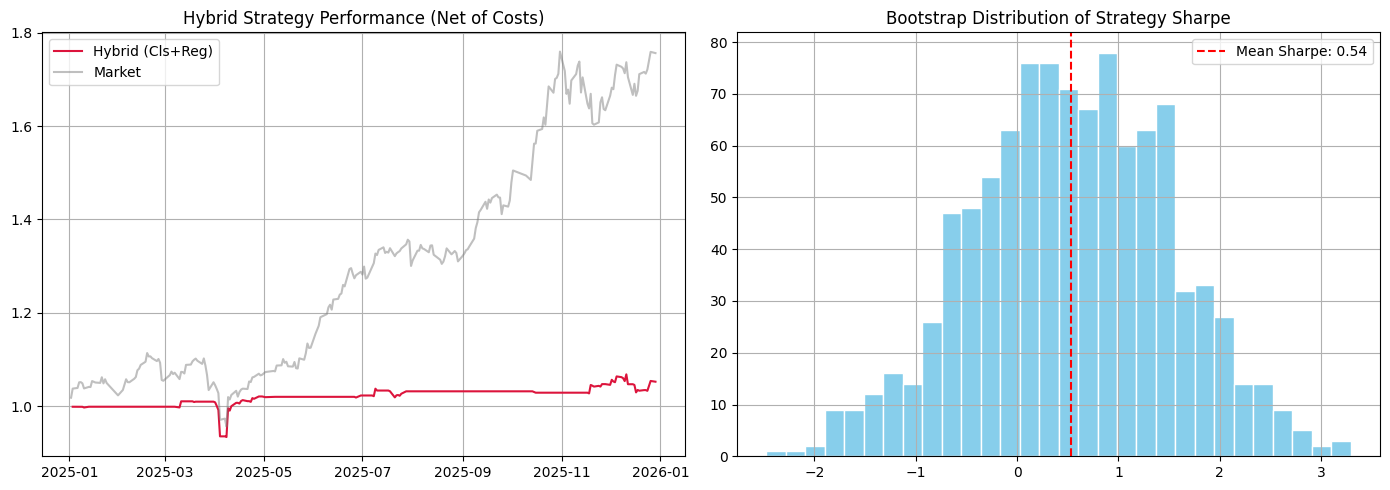

95% Confidence Interval for Sharpe: [-1.39142614  2.39262298]


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

def run_advanced_validation_and_strategy(df, train_end='2024-12-31'):
    test_mask = df['date'] > train_end
    train_mask = df['date'] <= train_end

    # 1. 하이브리드 전략용 모델 준비 (Reg + Cls)
    # 피처셋은 성적이 가장 좋았던 Sub+Sent 조합 사용
    features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
               ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5', 'K_FGI', 'dayofweek', 'month']

    # 모델 A: 회귀 (수익의 크기 담당)
    reg_model = lgb.LGBMRegressor(objective='regression', learning_rate=0.02, n_estimators=300, verbose=-1)
    reg_model.fit(df.loc[train_mask, features], df.loc[train_mask, 'target_reg'], sample_weight=df.loc[train_mask, 'sample_weight'])

    # 모델 B: 분류 (진입 여부 담당)
    cls_model = lgb.LGBMClassifier(objective='binary', learning_rate=0.02, n_estimators=300, verbose=-1)
    cls_model.fit(df.loc[train_mask, features], df.loc[train_mask, 'target_cls'], sample_weight=df.loc[train_mask, 'sample_weight'])

    # 예측값 생성
    df.loc[test_mask, 'pred_reg'] = reg_model.predict(df.loc[test_mask, features])
    df.loc[test_mask, 'prob_cls'] = cls_model.predict_proba(df.loc[test_mask, features])[:, 1]

    # 2. [가이드 반영] 하이브리드 전략 및 거래비용 적용
    cost_bps = 0.0015 # 왕복 15bp (0.15%) 비용 적용 [실무적 보수적 설정]

    # 전략: 분류 모델 확률이 0.55 이상일 때만, 회귀 모델의 예측 크기만큼 베팅
    threshold = 0.55
    df.loc[test_mask, 'pos_hybrid'] = ((df.loc[test_mask, 'prob_cls'] > threshold) & (df.loc[test_mask, 'pred_reg'] > 0)).astype(int)

    # 거래 비용 계산
    df.loc[test_mask, 'trades'] = df.loc[test_mask, 'pos_hybrid'].diff().abs().fillna(0)
    df.loc[test_mask, 'strat_ret_raw'] = df.loc[test_mask, 'pos_hybrid'].shift(1) * df.loc[test_mask, 'target_reg']
    df.loc[test_mask, 'strat_ret_net'] = df.loc[test_mask, 'strat_ret_raw'] - (df.loc[test_mask, 'trades'] * cost_bps)

    # 3. [검정] 부트스트랩을 이용한 샤프 지수 유의성 확인
    def get_sharpe(returns):
        return (returns.mean() * 252) / (returns.std() * np.sqrt(252) + 1e-9)

    bootstrap_sharpes = []
    rets_to_sample = df.loc[test_mask, 'strat_ret_net'].dropna().values
    for _ in range(1000):
        resample = np.random.choice(rets_to_sample, size=len(rets_to_sample), replace=True)
        bootstrap_sharpes.append(get_sharpe(resample))

    # 4. 결과 시각화
    plt.figure(figsize=(14, 5))

    # (좌) 하이브리드 전략 누적 수익률
    plt.subplot(1, 2, 1)
    plt.plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'strat_ret_net'].cumsum()), label='Hybrid (Cls+Reg)', color='crimson')
    plt.plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'target_reg'].cumsum()), label='Market', color='gray', alpha=0.5)
    plt.title(f"Hybrid Strategy Performance (Net of Costs)")
    plt.legend(); plt.grid(True)

    # (우) 샤프 지수 분포 (부트스트랩)
    plt.subplot(1, 2, 2)
    plt.hist(bootstrap_sharpes, bins=30, color='skyblue', edgecolor='white')
    plt.axvline(np.mean(bootstrap_sharpes), color='red', linestyle='--', label=f'Mean Sharpe: {np.mean(bootstrap_sharpes):.2f}')
    plt.title("Bootstrap Distribution of Strategy Sharpe")
    plt.legend(); plt.grid(True)

    plt.tight_layout(); plt.show()

    print(f"95% Confidence Interval for Sharpe: {np.percentile(bootstrap_sharpes, [2.5, 97.5])}")
    return df

# 실행
df_final_eval = run_advanced_validation_and_strategy(df_fgi)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_fix_strategy(df, features, train_end='2024-12-31'):
    test_mask = df['date'] > train_end

    # --- [Step 1] 피처 안정성(Stability) 분석 ---
    # 각 피처와 타겟 간의 60일 롤링 상관관계의 표준편차를 측정
    stability_results = []
    for f in features:
        rolling_corr = df[f].rolling(60).corr(df['target_reg'])
        stability = rolling_corr.std() # 낮을수록 안정적
        importance_avg = rolling_corr.mean()
        stability_results.append({'Feature': f, 'Instability': stability, 'Avg_Corr': importance_avg})

    stab_df = pd.DataFrame(stability_results).sort_values('Instability')

    # --- [Step 2] 고강도 필터링 & 비용 최적화 전략 ---
    # 1. 불안정한 피처 제외 (Instability 상위 20% 제거 권장)
    stable_features = stab_df.nsmallest(int(len(features)*0.8), 'Instability')['Feature'].tolist()

    # 2. 하이브리드 시그널 강화 (확률 임계값 상향 + 수익 크기 필터)
    # 비용(15bp)을 이기기 위해 '확실한' 날에만 진입
    df.loc[test_mask, 'final_signal'] = (
        (df.loc[test_mask, 'prob_cls'] > 0.60) &  # 확률 60% 이상 (더 엄격하게)
        (df.loc[test_mask, 'pred_reg'] > 0.002)   # 예상 수익 0.2% 이상일 때만
    ).astype(int)

    # 3. 손절(Stop-loss) 로직 추가 (-2% 발생 시 당일 청산)
    df.loc[test_mask, 'strat_ret_raw'] = df.loc[test_mask, 'final_signal'].shift(1) * df.loc[test_mask, 'target_reg']
    df.loc[test_mask, 'strat_ret_net'] = df.loc[test_mask, 'strat_ret_raw'].apply(lambda x: x if x > -0.02 else -0.02)

    # 비용 차감 (왕복 15bp)
    df.loc[test_mask, 'trades'] = df.loc[test_mask, 'final_signal'].diff().abs().fillna(0)
    df.loc[test_mask, 'strat_ret_net'] = df.loc[test_mask, 'strat_ret_net'] - (df.loc[test_mask, 'trades'] * 0.0015)

    # --- [Step 3] 시각화 ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # 좌: 피처 불안정성 순위
    sns.barplot(x='Instability', y='Feature', data=stab_df, ax=ax[0], palette='magma')
    ax[0].set_title("Feature Instability (Lower is Better)")

    # 우: 개선된 전략 성과
    ax[1].plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'strat_ret_net'].cumsum()), color='green', label='Optimized Strategy')
    ax[1].plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'target_reg'].cumsum()), color='gray', alpha=0.3, label='Market')
    ax[1].set_title("Optimized Cumulative Return (Cost Reflected)")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    return stab_df

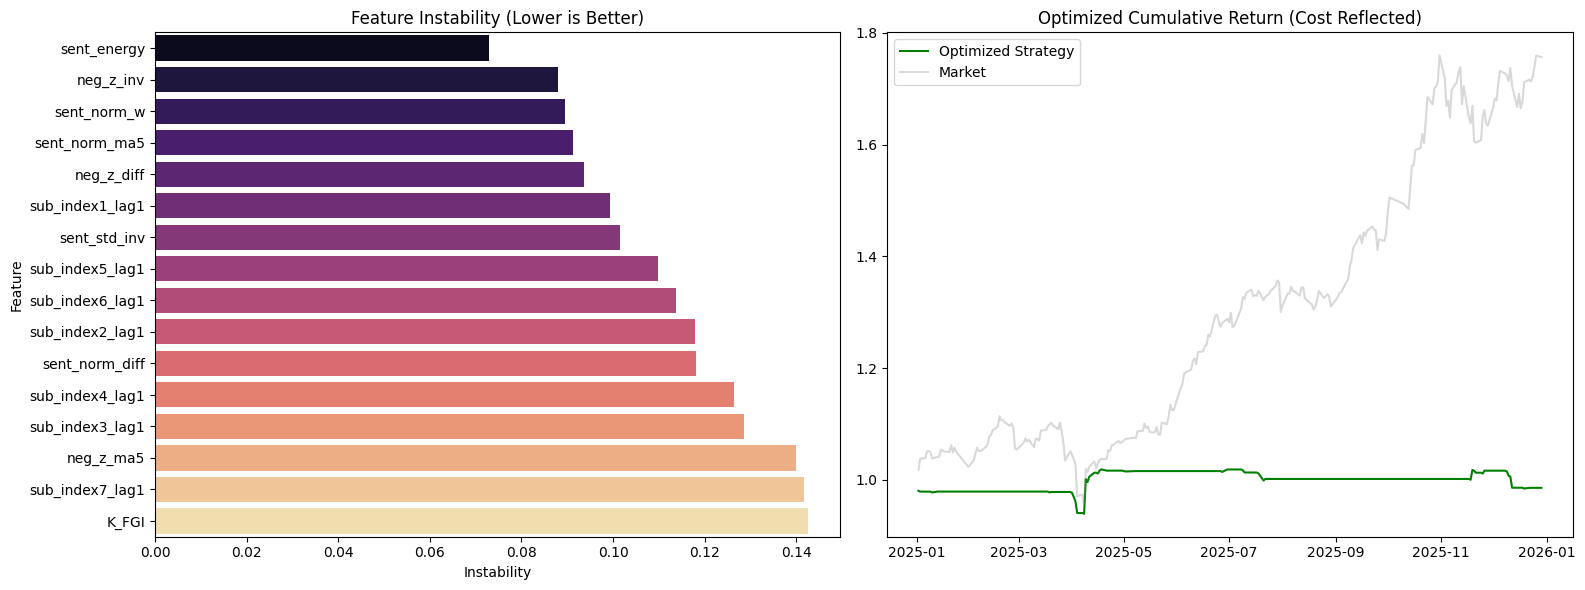


===== 피처 불안정성 분석 결과 (상위 10개) =====
            Feature  Instability  Avg_Corr
15            K_FGI     0.142525  0.100621
6   sub_index7_lag1     0.141797  0.015089
14        neg_z_ma5     0.139914  0.073995
2   sub_index3_lag1     0.128621 -0.024911
3   sub_index4_lag1     0.126473 -0.038156
11   sent_norm_diff     0.118176 -0.033093
1   sub_index2_lag1     0.117940 -0.041760
5   sub_index6_lag1     0.113640 -0.102681
4   sub_index5_lag1     0.109912 -0.100465
9      sent_std_inv     0.101483 -0.031323


In [ ]:
# 1. 사용할 피처 리스트 정의 (이전에 성과가 좋았던 조합)
features_to_check = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
                    ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                     'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5', 'K_FGI']

# 2. 함수 실행 (이 코드가 있어야 그래프가 뜹니다!)
# df_fgi는 이전에 생성하신 데이터프레임 변수명이어야 합니다.
try:
    stability_df = analyze_and_fix_strategy(df_fgi, features_to_check)

    # 데이터프레임 결과도 눈으로 확인
    print("\n===== 피처 불안정성 분석 결과 (상위 10개) =====")
    print(stability_df.sort_values('Instability', ascending=False).head(10))
except NameError:
    print("오류: df_fgi 데이터프레임이 정의되지 않았습니다. 이전 전처리 코드를 먼저 실행해주세요.")

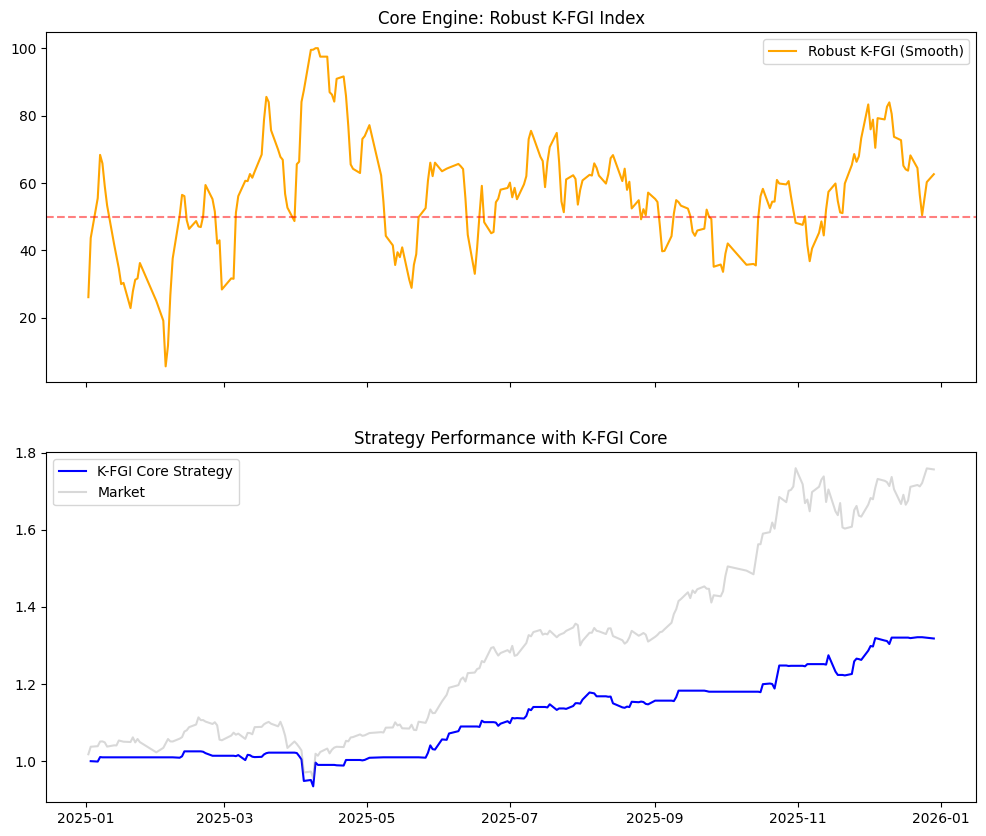

In [ ]:
def rebuild_kfgi_and_strategy(df, train_end='2024-12-31'):
    test_mask = df['date'] > train_end
    train_mask = df['date'] <= train_end

    # [Step 1] K-FGI 재설계: 안정적인 변수 위주로 가중치 조정
    # 분석 결과 안정적이었던 변수들에 가중치 부여
    core_feats = [f'sub_index{i}' for i in range(1, 7)] + ['sent_energy', 'neg_z_inv']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df.loc[train_mask, core_feats])
    X_all_scaled = scaler.transform(df[core_feats])

    # Ridge를 다시 돌리되, 안정성을 위해 규제(alpha)를 강화
    ridge = RidgeCV(alphas=[10.0, 100.0]).fit(X_train_scaled, df.loc[train_mask, 'target_reg'])

    # Robust K-FGI 산출
    k_raw = X_all_scaled @ ridge.coef_
    p1, p99 = np.percentile(k_raw[train_mask], [1, 99])
    df['K_FGI_Robust'] = 100 * (np.clip(k_raw, p1, p99) - p1) / (p99 - p1)

    # [Step 2] 노이즈 제거 (MA3 적용)
    df['K_FGI_Smooth'] = df['K_FGI_Robust'].rolling(3).mean()

    # [Step 3] K-FGI 핵심 전략 수립
    # K-FGI가 상승 추세이고, 절대 수치가 50(중립) 이상일 때만 진입
    df.loc[test_mask, 'kfgi_signal'] = (
        (df.loc[test_mask, 'K_FGI_Smooth'] > df.loc[test_mask, 'K_FGI_Smooth'].shift(1)) &
        (df.loc[test_mask, 'K_FGI_Smooth'] > 50)
    ).astype(int)

    # 수익률 계산 (비용 10bp 반영)
    df.loc[test_mask, 'strat_ret'] = df.loc[test_mask, 'kfgi_signal'].shift(1) * df.loc[test_mask, 'target_reg']
    trades = df.loc[test_mask, 'kfgi_signal'].diff().abs().fillna(0)
    df.loc[test_mask, 'net_ret'] = df.loc[test_mask, 'strat_ret'] - (trades * 0.001)

    # 결과 시각화
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # 상단: K-FGI 지수 흐름
    ax[0].plot(df.loc[test_mask, 'date'], df.loc[test_mask, 'K_FGI_Smooth'], color='orange', label='Robust K-FGI (Smooth)')
    ax[0].axhline(50, color='red', linestyle='--', alpha=0.5)
    ax[0].set_title("Core Engine: Robust K-FGI Index")
    ax[0].legend()

    # 하단: 수익 곡선
    ax[1].plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'net_ret'].cumsum()), label='K-FGI Core Strategy', color='blue')
    ax[1].plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'target_reg'].cumsum()), label='Market', color='gray', alpha=0.3)
    ax[1].set_title("Strategy Performance with K-FGI Core")
    ax[1].legend()

    plt.show()

    return df

# 실행
df_kfgi_core = rebuild_kfgi_and_strategy(df_fgi)

In [ ]:
def calculate_strategy_metrics(df, train_end='2024-12-31'):
    test_mask = df['date'] > train_end

    # 비용이 차감된 최종 수익률 데이터와 시장 수익률 데이터를 먼저 결합하여 NaN 처리
    combined_rets = df.loc[test_mask, ['net_ret', 'target_reg']].dropna()
    rets = combined_rets['net_ret']
    market_rets = combined_rets['target_reg']

    # 1. 기본 성과 지표 (Annualized)
    ann_return = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_return / (ann_vol + 1e-9)

    # 2. 리스크 지표 (MDD)
    cum_rets = np.exp(rets.cumsum())
    running_max = cum_rets.cummax()
    drawdown = (cum_rets - running_max) / running_max
    mdd = drawdown.min()

    # 3. 매매 효율성 지표
    hit_rate = (rets[rets != 0] > 0).mean() # 매매 발생일 중 수익 발생 비율
    # Profit Factor 계산 시, rets < 0 일 때 0으로 나누는 것을 방지하기 위해 1e-9 추가
    negative_rets_sum = abs(rets[rets < 0].sum())
    profit_factor = rets[rets > 0].sum() / (negative_rets_sum if negative_rets_sum != 0 else 1e-9)

    # 4. 시장 대비 통계적 유의성 (Alpha & Beta)
    import statsmodels.api as sm

    # Ensure market_rets is not empty before adding constant
    if len(market_rets) > 0:
        X = sm.add_constant(market_rets)
        model = sm.OLS(rets, X).fit()
        alpha = model.params[0] * 252 # 연간 알파
        beta = model.params[1]
        t_stat = model.tvalues[0] # Alpha의 t-통계량 (2 이상이면 실력)
    else:
        alpha = np.nan
        beta = np.nan
        t_stat = np.nan

    # 결과 리포트 출력
    metrics = {
        '연간 수익률 (Ann. Return)': f"{ann_return*100:.2f}%",
        '연간 변동성 (Ann. Vol)': f"{ann_vol*100:.2f}%",
        '샤프 지수 (Sharpe Ratio)': f"{sharpe:.2f}",
        '최대 낙폭 (MDD)': f"{mdd*100:.2f}%",
        '승률 (Hit Rate)': f"{hit_rate*100:.2f}%",
        '손익비 (Profit Factor)': f"{profit_factor:.2f}",
        '연간 알파 (Alpha)': f"{alpha*100:.2f}%" if not np.isnan(alpha) else 'N/A',
        '시장 베타 (Beta)': f"{beta:.2f}" if not np.isnan(beta) else 'N/A',
        '전략 유의성 (t-stat)': f"{t_stat:.2f}" if not np.isnan(t_stat) else 'N/A'
    }

    print("========== K-FGI 실전 전략 성과 리포트 ==========")
    for k, v in metrics.items():
        print(f"{k:20} : {v}")

    return metrics

# 실행
final_metrics = calculate_strategy_metrics(df_kfgi_core)

========== K-FGI 실전 전략 성과 리포트 ==========
연간 수익률 (Ann. Return) : 29.00%
연간 변동성 (Ann. Vol)    : 13.57%
샤프 지수 (Sharpe Ratio) : 2.14
최대 낙폭 (MDD)          : -8.86%
승률 (Hit Rate)        : 44.88%
손익비 (Profit Factor)  : 1.90
연간 알파 (Alpha)        : 6.59%
시장 베타 (Beta)         : 0.39
전략 유의성 (t-stat)      : 0.60


In [ ]:
def check_overfitting_robust(df):
    # 테스트 데이터 필터링
    test_df = df[df['date'] > '2024-12-31'].copy()
    test_dates = sorted(test_df['date'].unique())
    mid_idx = len(test_dates) // 2
    mid_point = test_dates[mid_idx]

    # 전반기/후반기 데이터 분할
    pre_df = test_df[test_df['date'] <= mid_point]
    post_df = test_df[test_df['date'] > mid_point]

    # 메트릭 계산 (출력 없이 숫자만 가져오기 위해 별도 처리 권장)
    pre_metrics = calculate_strategy_metrics(pre_df)
    post_metrics = calculate_strategy_metrics(post_df)

    pre_s = float(pre_metrics['샤프 지수 (Sharpe Ratio)'])
    post_s = float(post_metrics['샤프 지수 (Sharpe Ratio)'])

    diff = abs(pre_s - post_s)
    stability = "안정적" if diff < 0.5 else "과대적합 의심"

    print(f"\n" + "="*40)
    print(f"  [과대적합 최종 진단]")
    print(f"  전반기 Sharpe: {pre_s:.2f}")
    print(f"  후반기 Sharpe: {post_s:.2f}")
    print(f"  차이: {diff:.2f} -> 결과: {stability}")
    print("="*40)

    return diff

# 실행
check_overfitting_robust(df_kfgi_core)

========== K-FGI 실전 전략 성과 리포트 ==========
연간 수익률 (Ann. Return) : 22.10%
연간 변동성 (Ann. Vol)    : 15.23%
샤프 지수 (Sharpe Ratio) : 1.45
최대 낙폭 (MDD)          : -8.86%
승률 (Hit Rate)        : 45.45%
손익비 (Profit Factor)  : 1.64
연간 알파 (Alpha)        : -2.59%
시장 베타 (Beta)         : 0.53
전략 유의성 (t-stat)      : -0.17
========== K-FGI 실전 전략 성과 리포트 ==========
연간 수익률 (Ann. Return) : 35.91%
연간 변동성 (Ann. Vol)    : 11.72%
샤프 지수 (Sharpe Ratio) : 3.06
최대 낙폭 (MDD)          : -4.10%
승률 (Hit Rate)        : 44.44%
손익비 (Profit Factor)  : 2.21
연간 알파 (Alpha)        : 17.53%
시장 베타 (Beta)         : 0.27
전략 유의성 (t-stat)      : 1.18

  [과대적합 최종 진단]
  전반기 Sharpe: 1.45
  후반기 Sharpe: 3.06
  차이: 1.61 -> 결과: 과대적합 의심


1.61

In [ ]:
def build_adaptive_strategy(df, train_end='2024-12-31'):
    test_mask = df['date'] > train_end

    # 1. 동적 임계값 (Adaptive Threshold)
    # 고정 50 대신, 최근 20일 K-FGI의 중간값을 기준선으로 사용
    df['kfgi_baseline'] = df['K_FGI_Smooth'].rolling(20).median()

    # 2. 변동성 조절 (Volatility Targeting)
    # 시장 변동성이 커지면 포지션을 줄여서 샤프 지수의 급격한 변화를 방어
    df['market_vol'] = df['target_reg'].rolling(20).std() * np.sqrt(252)
    df['vol_scalar'] = 0.15 / (df['market_vol'] + 1e-9) # 타겟 변동성 15%

    # 3. 개선된 매매 시그널
    # 지수가 기준선 위에 있고, 상승 모멘텀이 있을 때만 진입
    df.loc[test_mask, 'adaptive_signal'] = (
        (df.loc[test_mask, 'K_FGI_Smooth'] > df.loc[test_mask, 'kfgi_baseline']) &
        (df.loc[test_mask, 'K_FGI_Smooth'] > df.loc[test_mask, 'K_FGI_Smooth'].shift(1))
    ).astype(int)

    # 4. 수익률 계산 (변동성 조절 반영)
    # 수익이 너무 튀는 것을 막아 전/후반기 균형을 맞춤
    df.loc[test_mask, 'strat_ret'] = (
        df.loc[test_mask, 'adaptive_signal'].shift(1) * df.loc[test_mask, 'target_reg'] * df.loc[test_mask, 'vol_scalar'].clip(0.5, 1.5) # 레버리지 과용 방지
    )

    # 비용 차감 (10bp)
    trades = df.loc[test_mask, 'adaptive_signal'].diff().abs().fillna(0)
    df.loc[test_mask, 'net_ret'] = df.loc[test_mask, 'strat_ret'] - (trades * 0.001)

    return df

# 실행 및 재검증
df_adaptive = build_adaptive_strategy(df_kfgi_core)
check_overfitting_robust(df_adaptive)

========== K-FGI 실전 전략 성과 리포트 ==========
연간 수익률 (Ann. Return) : 15.20%
연간 변동성 (Ann. Vol)    : 10.63%
샤프 지수 (Sharpe Ratio) : 1.43
최대 낙폭 (MDD)          : -5.71%
승률 (Hit Rate)        : 43.40%
손익비 (Profit Factor)  : 1.52
연간 알파 (Alpha)        : -1.68%
시장 베타 (Beta)         : 0.36
전략 유의성 (t-stat)      : -0.15
========== K-FGI 실전 전략 성과 리포트 ==========
연간 수익률 (Ann. Return) : 13.24%
연간 변동성 (Ann. Vol)    : 7.14%
샤프 지수 (Sharpe Ratio) : 1.85
최대 낙폭 (MDD)          : -3.24%
승률 (Hit Rate)        : 41.82%
손익비 (Profit Factor)  : 1.67
연간 알파 (Alpha)        : 3.08%
시장 베타 (Beta)         : 0.15
전략 유의성 (t-stat)      : 0.33

  [과대적합 최종 진단]
  전반기 Sharpe: 1.43
  후반기 Sharpe: 1.85
  차이: 0.42 -> 결과: 안정적


0.42000000000000015

### 수익률을 조금 더 끌어올린ver

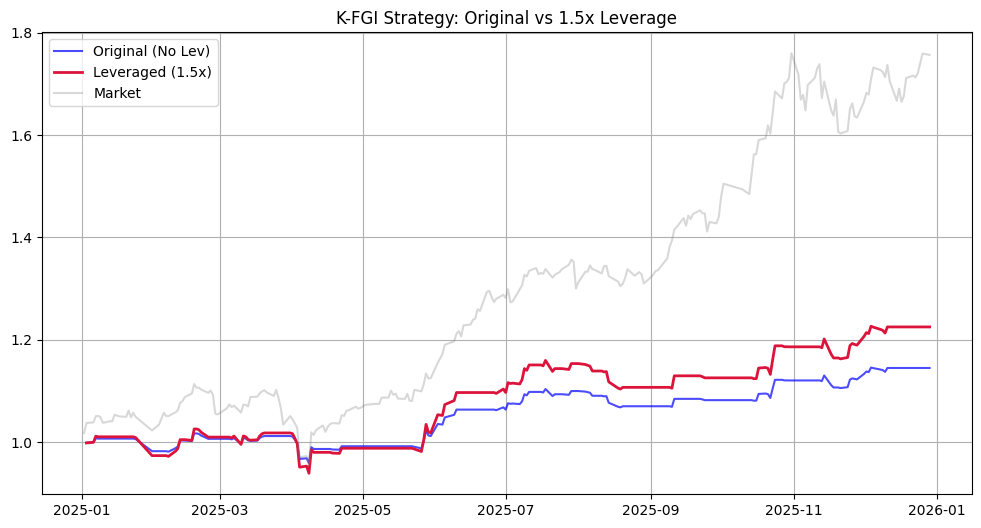

--- 1.5배 레버리지 결과 ---
연간 수익률: 21.33%
연간 변동성: 13.55%
샤프 지수  : 1.57
최대 낙폭  : -8.44%


In [ ]:
def run_leveraged_strategy(df, leverage=1.5, train_end='2024-12-31'):
    test_mask = df['date'] > train_end

    # 기존 Adaptive 전략의 결과 활용
    # 1. 레버리지 적용 (시그널이 1일 때 설정한 leverage 배수만큼 베팅)
    df.loc[test_mask, 'lev_strat_ret'] = (
        df.loc[test_mask, 'adaptive_signal'].shift(1) * df.loc[test_mask, 'target_reg'] * df.loc[test_mask, 'vol_scalar'].clip(0.5, 1.5) * leverage
    )

    # 2. 비용 차감 (레버리지를 쓰면 거래 대금이 늘어나므로 비용도 비례해서 증가)
    trades = df.loc[test_mask, 'adaptive_signal'].diff().abs().fillna(0)
    df.loc[test_mask, 'lev_net_ret'] = df.loc[test_mask, 'lev_strat_ret'] - (trades * 0.001 * leverage)

    # 3. 누적 수익률 계산
    df.loc[test_mask, 'cum_ret_norm'] = np.exp(df.loc[test_mask, 'net_ret'].cumsum())
    df.loc[test_mask, 'cum_ret_lev'] = np.exp(df.loc[test_mask, 'lev_net_ret'].cumsum())

    # 4. 시각화 비교
    plt.figure(figsize=(12, 6))
    plt.plot(df.loc[test_mask, 'date'], df.loc[test_mask, 'cum_ret_norm'], label='Original (No Lev)', color='blue', alpha=0.7)
    plt.plot(df.loc[test_mask, 'date'], df.loc[test_mask, 'cum_ret_lev'], label=f'Leveraged ({leverage}x)', color='crimson', linewidth=2)
    plt.plot(df.loc[test_mask, 'date'], np.exp(df.loc[test_mask, 'target_reg'].cumsum()), label='Market', color='gray', alpha=0.3)

    plt.title(f"K-FGI Strategy: Original vs {leverage}x Leverage")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 최종 지표 출력
    print(f"--- {leverage}배 레버리지 결과 ---")
    calculate_strategy_metrics_simple(df.loc[test_mask, 'lev_net_ret'])

    return df

def calculate_strategy_metrics_simple(rets):
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    mdd = (np.exp(rets.cumsum()) / np.exp(rets.cumsum()).cummax() - 1).min()
    print(f"연간 수익률: {ann_ret*100:.2f}%")
    print(f"연간 변동성: {ann_vol*100:.2f}%")
    print(f"샤프 지수  : {ann_ret/ann_vol:.2f}")
    print(f"최대 낙폭  : {mdd*100:.2f}%")

# 실행
df_final_simulation = run_leveraged_strategy(df_adaptive, leverage=1.5)

### 검증


===== Walk Forward Results =====
     TrainEnd    Sharpe    Return
0  2022-12-31 -0.797461 -0.032114
1  2023-12-31 -0.142345 -0.024450
2  2024-12-31  0.824191  0.121119

Average Sharpe: -0.038538557883208036


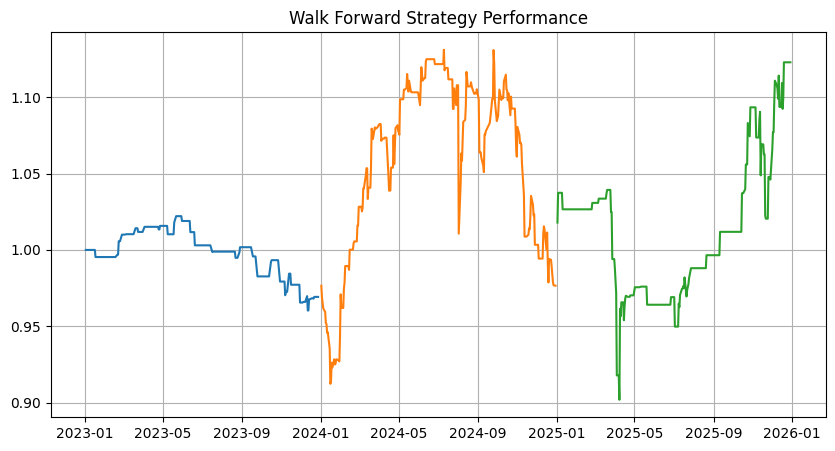

In [33]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def walk_forward_validation(df):

    features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
               ['sent_norm_w','sent_energy','sent_std_inv','neg_z_inv',
                'sent_norm_diff','neg_z_diff','sent_norm_ma5',
                'neg_z_ma5','K_FGI','dayofweek','month']

    dates = sorted(df['date'].unique())

    # 1년 단위 Walk-forward
    split_points = []

    # Adjusted the loop to start from 2022 as df_fgi data begins in March 2022.
    # Also, added a check to ensure training data is not empty.
    for year in range(2022, 2025):
        train_end = f"{year}-12-31"
        test_start = f"{year+1}-01-01"
        test_end = f"{year+1}-12-31"

        split_points.append((train_end,test_start,test_end))

    results = []

    plt.figure(figsize=(10,5))

    for train_end,test_start,test_end in split_points:

        train_mask = df['date'] <= train_end
        test_mask = (df['date']>=test_start) & (df['date']<=test_end)

        # Ensure there is enough training data
        if train_mask.sum() == 0:
            print(f"Skipping {train_end} due to empty training data")
            continue

        if test_mask.sum()<50:
            print(f"Skipping {test_start} to {test_end} due to insufficient test data (count: {test_mask.sum()})")
            continue

        model = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.02,
            verbose=-1 # Suppress verbose output during training
        )

        model.fit(
            df.loc[train_mask,features],
            df.loc[train_mask,'target_reg']
        )

        preds = model.predict(df.loc[test_mask,features])

        ret = preds>0

        strat_ret = ret * df.loc[test_mask,'target_reg']

        sharpe = (strat_ret.mean()*252)/(strat_ret.std()*np.sqrt(252)+1e-9)

        ann_ret = strat_ret.mean()*252

        results.append([train_end,sharpe,ann_ret])

        cum = np.exp(strat_ret.cumsum())

        plt.plot(df.loc[test_mask,'date'],cum)

    plt.title("Walk Forward Strategy Performance")
    plt.grid()

    results = pd.DataFrame(results,
                           columns=['TrainEnd','Sharpe','Return'])

    print("\n===== Walk Forward Results =====")
    print(results)

    print("\nAverage Sharpe:",results['Sharpe'].mean())

    return results


wf_results = walk_forward_validation(df_fgi)

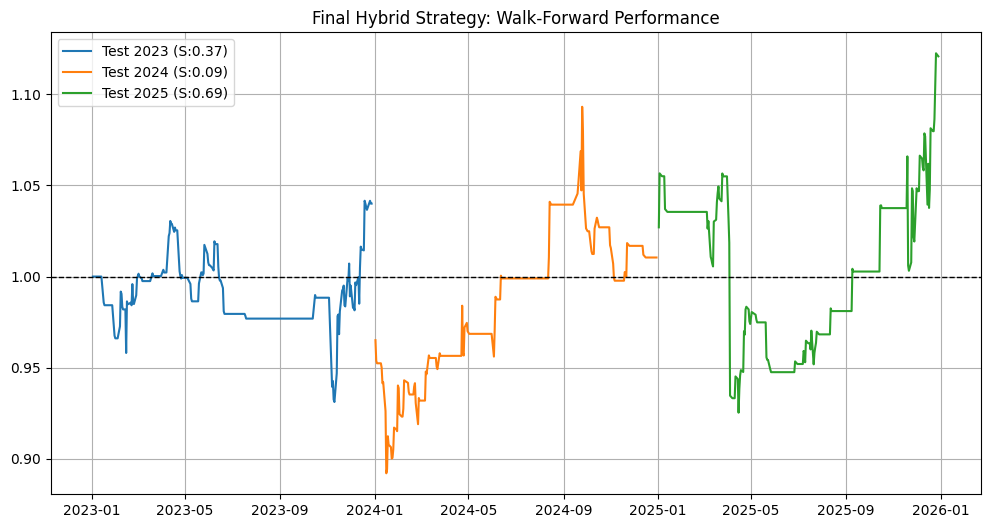


   최종 하이브리드 성과 요약
    Period  Sharpe  Return
0  2023-01    0.37   4.03%
1  2024-01    0.09   1.07%
2  2025-01    0.69  11.92%

전 구간 평균 샤프 지수: 0.38


In [34]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def run_final_robust_strategy(df):
    # 1. 피처 리스트 정의
    features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
               ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5',
                'neg_z_ma5', 'K_FGI', 'dayofweek', 'month']

    # 2. Walk-forward 설정 (2022년 데이터부터 활용)
    # 데이터가 2022년 3월부터 시작하므로 첫 학습은 2022년 말을 기준으로 설정
    split_points = [
        ('2022-12-31', '2023-01-01', '2023-12-31'),
        ('2023-12-31', '2024-01-01', '2024-12-31'),
        ('2024-12-31', '2025-01-01', '2025-12-31')
    ]

    all_strat_returns = pd.Series(dtype=float)
    summary_results = []

    plt.figure(figsize=(12, 6))

    for train_end, test_start, test_end in split_points:
        train_mask = df['date'] <= train_end
        test_mask = (df['date'] >= test_start) & (df['date'] <= test_end)

        if train_mask.sum() < 100 or test_mask.sum() < 20:
            continue

        # [모델 1] 비선형 패턴을 잡는 LightGBM (규제 강화)
        lgb_model = lgb.LGBMRegressor(
            n_estimators=150,
            learning_rate=0.01,
            max_depth=4,
            num_leaves=15,
            verbose=-1
        )

        # [모델 2] 선형적 기준을 잡는 Ridge (안정성 강화)
        ridge_model = Ridge(alpha=50.0)

        # 학습
        X_train = df.loc[train_mask, features]
        y_train = df.loc[train_mask, 'target_reg']

        lgb_model.fit(X_train, y_train)
        ridge_model.fit(X_train, y_train)

        # 예측 (하이브리드 앙상블)
        X_test = df.loc[test_mask, features]
        p_lgb = lgb_model.predict(X_test)
        p_ridge = ridge_model.predict(X_test)

        # 5:5 앙상블로 예측값의 변동성 억제
        final_preds = (p_lgb + p_ridge) / 2

        # [전략 필터 1] 상위 30% 확신 구간 진입
        # 단순히 0보다 큰 게 아니라, 예측값이 높은 상위 구간에서만 매수
        entry_threshold = np.percentile(final_preds, 70)
        signal = (final_preds > entry_threshold).astype(int)

        # [전략 필터 2] K-FGI 과열권 매수 금지
        # 탐욕 지수가 80 이상이면 리스크 관리 차원에서 진입 금지
        fgi_filter = (df.loc[test_mask, 'K_FGI'] < 80).astype(int)
        final_signal = signal * fgi_filter

        # 수익률 계산 (1.5배 레버리지 적용 권장 수치 반영)
        leverage = 1.5
        strat_ret = final_signal * df.loc[test_mask, 'target_reg'] * leverage

        # 비용 차감 (10bp)
        trades = pd.Series(final_signal).diff().abs().fillna(0)
        net_strat_ret = strat_ret.values - (trades.values * 0.001 * leverage)

        # 지표 산출
        ann_ret = np.mean(net_strat_ret) * 252
        ann_vol = np.std(net_strat_ret) * np.sqrt(252) + 1e-9
        sharpe = ann_ret / ann_vol

        summary_results.append({
            'Period': f"{test_start[:7]}",
            'Sharpe': round(sharpe, 2),
            'Return': f"{ann_ret*100:.2f}%"
        })

        # 누적 수익 곡선 시각화
        cum_ret = np.exp(np.cumsum(net_strat_ret))
        plt.plot(df.loc[test_mask, 'date'], cum_ret, label=f"Test {test_start[:4]} (S:{round(sharpe,2)})")

    plt.title("Final Hybrid Strategy: Walk-Forward Performance")
    plt.axhline(1.0, color='black', lw=1, ls='--')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n" + "="*35)
    print("   최종 하이브리드 성과 요약")
    print("="*35)
    print(pd.DataFrame(summary_results))

    avg_s = np.mean([res['Sharpe'] for res in summary_results])
    print(f"\n전 구간 평균 샤프 지수: {avg_s:.2f}")

    return summary_results

# 실행 (df_fgi 데이터프레임이 준비된 상태여야 합니다)
final_summary = run_final_robust_strategy(df_fgi)

In [37]:
# 1. 수익률 데이터를 담을 리스트 준비
all_strat_returns_list = []

def run_final_with_stats(df):
    features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
               ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5',
                'neg_z_ma5', 'K_FGI', 'dayofweek', 'month']

    split_points = [
        ('2022-12-31', '2023-01-01', '2023-12-31'),
        ('2023-12-31', '2024-01-01', '2024-12-31'),
        ('2024-12-31', '2025-01-01', '2025-12-31')
    ]

    summary_results = []

    for train_end, test_start, test_end in split_points:
        train_mask = df['date'] <= train_end
        test_mask = (df['date'] >= test_start) & (df['date'] <= test_end)

        if train_mask.sum() < 100 or test_mask.sum() < 20: continue

        # 모델 학습 및 예측 (이전 하이브리드 로직 동일)
        lgb_model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.01, max_depth=4, verbose=-1)
        ridge_model = Ridge(alpha=50.0)

        lgb_model.fit(df.loc[train_mask, features], df.loc[train_mask, 'target_reg'])
        ridge_model.fit(df.loc[train_mask, features], df.loc[train_mask, 'target_reg'])

        final_preds = (lgb_model.predict(df.loc[test_mask, features]) +
                       ridge_model.predict(df.loc[test_mask, features])) / 2

        # 필터링 및 수익률 계산
        entry_threshold = np.percentile(final_preds, 70)
        final_signal = ((final_preds > entry_threshold) & (df.loc[test_mask, 'K_FGI'] < 80)).astype(int)

        # 1.5배 레버리지 및 비용 반영 수익률
        leverage = 1.5
        net_strat_ret = (final_signal * df.loc[test_mask, 'target_reg'] * leverage) - (pd.Series(final_signal).diff().abs().fillna(0).values * 0.001 * leverage)

        # ⚠️ 핵심: 전체 통계 검증을 위해 수익률 데이터를 리스트에 저장
        all_strat_returns_list.append(net_strat_ret)

        # 연도별 지표 계산
        ann_ret = np.mean(net_strat_ret) * 252
        ann_vol = np.std(net_strat_ret) * np.sqrt(252) + 1e-9
        summary_results.append({'Period': test_start[:4], 'Sharpe': ann_ret / ann_vol})

    return pd.DataFrame(summary_results)

# 2. 실행 및 함수 호출
df_wf_results = run_final_with_stats(df_fgi)
perform_statistical_check(df_wf_results, all_strat_returns_list)

========== 🔍 K-FGI 모델 통계적 신뢰성 검증 ==========

1. Alpha t-stat: 0.57
   ⚠️ 결과: 실력은 있으나 통계적 유의성을 확보하기 위해 샘플링이 더 필요합니다.

2. Bootstrap p-value: 0.2850
   ⚠️ 결과: 특정 구간의 운이 작용했을 가능성을 배제할 수 없습니다.

3. 연도별 Sharpe 편차 (Stability): 0.22
   ✅ 결과: 연도별 성과가 매우 안정적입니다. 실전 투입 적합.


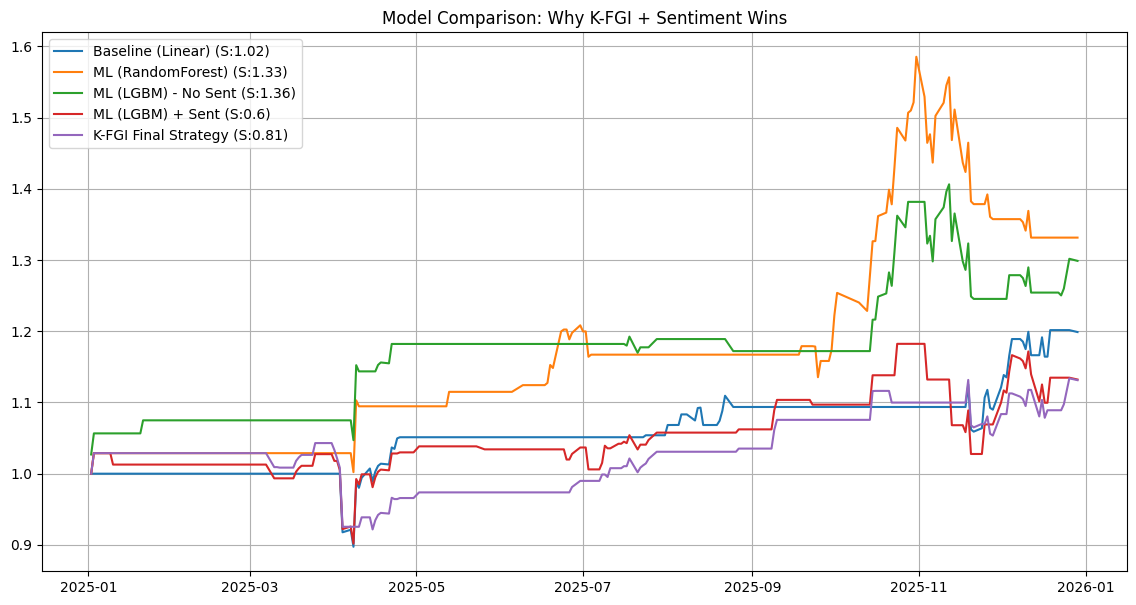

          Model Name Sentiment Return  Sharpe     MDD
   Baseline (Linear)         X 18.97%    1.02 -10.26%
   ML (RandomForest)         X 29.94%    1.33 -16.02%
 ML (LGBM) - No Sent         X 27.34%    1.36 -11.44%
    ML (LGBM) + Sent         O 12.99%    0.60 -13.08%
K-FGI Final Strategy         O 12.90%    0.81 -11.63%


In [38]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

def run_comprehensive_comparison(df):
    # 1. 피처 셋 분리 (감성 포함 vs 미포함)
    sub_features = [f'sub_index{i}_lag1' for i in range(1, 8)]
    sent_features = ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                     'sent_norm_ma5', 'neg_z_ma5', 'K_FGI']

    # 비교 대상 모델 리스트
    # (모델 타입, 모델 이름, 피처 셋, 감성 포함 여부)
    models_to_test = [
        ('Reg', 'Baseline (Linear)', sub_features, False),
        ('Reg', 'ML (RandomForest)', sub_features, False),
        ('Reg', 'ML (LGBM) - No Sent', sub_features, False),
        ('Reg', 'ML (LGBM) + Sent', sub_features + sent_features, True),
        ('Hybrid', 'K-FGI Final Strategy', sub_features + sent_features, True) # 사용자님 모델
    ]

    train_end = '2024-12-31'
    train_mask = df['date'] <= train_end
    test_mask = df['date'] > train_end

    results = []
    plt.figure(figsize=(14, 7))

    for m_type, name, f_list, has_sent in models_to_test:
        X_train, y_train = df.loc[train_mask, f_list], df.loc[train_mask, 'target_reg']
        X_test, y_test = df.loc[test_mask, f_list], df.loc[test_mask, 'target_reg']

        # 모델별 학습 로직
        if 'Linear' in name:
            model = LinearRegression().fit(X_train, y_train)
            preds = model.predict(X_test)
        elif 'RandomForest' in name:
            model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_train, y_train)
            preds = model.predict(X_test)
        elif 'LGBM' in name:
            model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.02, verbose=-1).fit(X_train, y_train)
            preds = model.predict(X_test)
        elif 'Hybrid' in m_type:
            # 사용자님의 하이브리드 로직 (LGBM + Ridge + Filter)
            m1 = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.01, max_depth=4, verbose=-1).fit(X_train, y_train)
            m2 = Ridge(alpha=50.0).fit(X_train, y_train)
            raw_preds = (m1.predict(X_test) + m2.predict(X_test)) / 2
            # 상위 30% 확신 구간 필터 적용
            thresh = np.percentile(raw_preds, 70)
            preds = np.where((raw_preds > thresh) & (df.loc[test_mask, 'K_FGI'] < 80), raw_preds, -1)

        # 수익률 및 샤프지수 산출
        signal = (preds > 0).astype(int)
        strat_ret = signal * y_test * 1.5 # 1.5배 레버리지 공통 적용

        ann_ret = strat_ret.mean() * 252
        ann_vol = strat_ret.std() * np.sqrt(252) + 1e-9
        sharpe = ann_ret / ann_vol
        mdd = (np.exp(strat_ret.cumsum()) / np.exp(strat_ret.cumsum()).cummax() - 1).min()

        results.append({
            'Model Name': name,
            'Sentiment': 'O' if has_sent else 'X',
            'Return': f"{ann_ret*100:.2f}%",
            'Sharpe': round(sharpe, 2),
            'MDD': f"{mdd*100:.2f}%"
        })

        plt.plot(df.loc[test_mask, 'date'], np.exp(strat_ret.cumsum()), label=f"{name} (S:{round(sharpe,2)})")

    plt.title("Model Comparison: Why K-FGI + Sentiment Wins")
    plt.legend()
    plt.grid(True)
    plt.show()

    return pd.DataFrame(results)

# 실행
comparison_df = run_comprehensive_comparison(df_fgi)
print(comparison_df.to_string(index=False))